In [1]:
import numpy as np
from pyscf import gto, scf, lo, mp, cc
mol = gto.Mole()
mol.verbose = 4
mol.atom = '''
O   -1.485163346097   -0.114724564047    0.000000000000
H   -1.868415346097    0.762298435953    0.000000000000
H   -0.533833346097    0.040507435953    0.000000000000
O    1.416468653903    0.111264435953    0.000000000000
H    1.746241653903   -0.373945564047   -0.758561000000
H    1.746241653903   -0.373945564047    0.758561000000
'''
mol.basis = 'cc-pvdz'
mol.precision = 1e-10
mol.build()
mf = scf.RHF(mol).density_fit()
mf.kernel()

frozen = 2
mymp = mp.MP2(mf, frozen=frozen)
mymp.kernel()
efull_mp2 = mymp.e_corr
print(f'MP2 Corr = {efull_mp2:.8f}')

mycc = cc.CCSD(mf, frozen=frozen)
mycc.kernel()
efull_ccsd = mycc.e_corr
print(f'CCSD Corr = {efull_ccsd:.8f}')

efull_t = mycc.ccsd_t()
efull_ccsd_t = efull_ccsd + efull_t
print(f'CCSD(T) Corr = {efull_ccsd_t:.8f}')

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-22-generic', version='#22~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Mar 26 15:25:54 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Mon May  4 19:16:52 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH 
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 6
[INPUT] num. electrons = 20
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT] 

In [3]:
print(f'MP2 Corr = {efull_mp2:.8f}')
print(f'CCSD Corr = {efull_ccsd:.8f}')
print(f'CCSD(T) Corr = {efull_ccsd_t:.8f}')

MP2 Corr = -0.40609899
CCSD Corr = -0.42461940
CCSD(T) Corr = -0.43105819


In [2]:
mol = mycc.mol
mf = mycc._scf
frozen = mycc.frozen

# PM localization
orbocc = mf.mo_coeff[:,frozen:np.count_nonzero(mf.mo_occ)]
mlo = lo.PipekMezey(mol, orbocc)
lo_coeff_pm = mlo.kernel()
while True: # always performing jacobi sweep to avoid trapping in local minimum/saddle point
    lo_coeff1 = mlo.stability_jacobi()[1]
    if lo_coeff1 is lo_coeff_pm:
        break
    mlo = lo.PipekMezey(mf.mol, lo_coeff1).set(verbose=4)
    mlo.init_guess = None
    lo_coeff_pm = mlo.kernel()



******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
pop_method = meta_lowdin
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 5.98868602976  delta_f= 5.98869  |g|= 0.314245  3 KF 17 Hx
macro= 2  f(x)= 6.0384175358487  delta_f= 0.0497315  |g|= 0.196967  3 KF 15 Hx
macro= 3  f(x)= 6.0597650539903  delta_f= 0.0213475  |g|= 0.0412846  2 KF 9 Hx
macro= 4  f(x)= 6.0597964288505  delta_f= 3.13749e-05  |g|= 0.000354428  2 KF 6 Hx
macro= 5  f(x)= 6.059796428851  delta_f= 4.69846e-13  |g|= 7.56989e-06  1 KF 1 Hx
macro X = 5  f(x)= 6.059796428851  |g|= 7.56989e-06  10 intor 11 KF 48 Hx
Jacobi sweep for 1 mo pairs: [(np.int64(2), np.int64(0))]


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e

In [ ]:
from pyscf.lno import LNOCCSD, LNOCCSD_T
from pyscf.lno.tools import autofrag_iao

# mol = mycc.mol
# mf = mycc._scf
# frozen = mycc.frozen

# # PM localization
# orbocc = mf.mo_coeff[:,frozen:np.count_nonzero(mf.mo_occ)]
# mlo = lo.PipekMezey(mol, orbocc)
# lo_coeff = mlo.kernel()
# while True: # always performing jacobi sweep to avoid trapping in local minimum/saddle point
#     lo_coeff1 = mlo.stability_jacobi()[1]
#     if lo_coeff1 is lo_coeff:
#         break
#     mlo = lo.PipekMezey(mf.mol, lo_coeff1).set(verbose=4)
#     mlo.init_guess = None
#     lo_coeff = mlo.kernel()

# Fragment list: for PM, every orbital corresponds to a fragment
frag_lolist = [[i] for i in range(lo_coeff.shape[1])]

gamma = 10
threshs = [3e-5,1e-5,3e-6,1e-6,3e-7]
print(f'Ref MP2 Corr = {efull_mp2:.8f}')
print(f'Ref CCSD Corr = {efull_ccsd:.8f}')
print(f'Ref CCSD(T) Corr = {efull_ccsd_t:.8f}')

# refs = [
#     [-0.4044781783,-0.4231598372,-0.4292049721],
#     [-0.4058765086,-0.4244510794,-0.4307864928],
# ]

emp2_pm = np.zeros(len(threshs))
eccsd_pm = np.zeros(len(threshs))
eccsd_t_pm = np.zeros(len(threshs))

for i, thresh in enumerate(threshs):
    mcc = LNOCCSD_T(mf, lo_coeff, frag_lolist, frozen=frozen).set(verbose=5)
    mcc.lno_thresh = [thresh*gamma,thresh]
    mcc.kernel()
    emp2_pm[i] = mcc.e_corr_pt2
    eccsd_pm[i] = mcc.e_corr_ccsd
    eccsd_t_pm[i] = mcc.e_corr_ccsd_t



******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
pop_method = meta_lowdin
Set conv_tol_grad to 0.000316228


macro= 1  f(x)= 5.98868602976  delta_f= 5.98869  |g|= 0.314245  3 KF 17 Hx
macro= 2  f(x)= 6.0384175358487  delta_f= 0.0497315  |g|= 0.196967  3 KF 15 Hx
macro= 3  f(x)= 6.0597650539903  delta_f= 0.0213475  |g|= 0.0412846  2 KF 9 Hx
macro= 4  f(x)= 6.0597964288506  delta_f= 3.13749e-05  |g|= 0.000354428  2 KF 6 Hx
macro= 5  f(x)= 6.059796428851  delta_f= 4.66294e-13  |g|= 7.56989e-06  1 KF 1 Hx
macro X = 5  f(x)= 6.059796428851  |g|= 7.56989e-06  10 intor 11 KF 48 Hx
Jacobi sweep for 1 mo pairs: [(np.int64(2), np.int64(0))]


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = None
pop_method = meta_lowdin
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 6.1707750448012  delta_f= 6.17078  |g|= 0.00509165  1 K

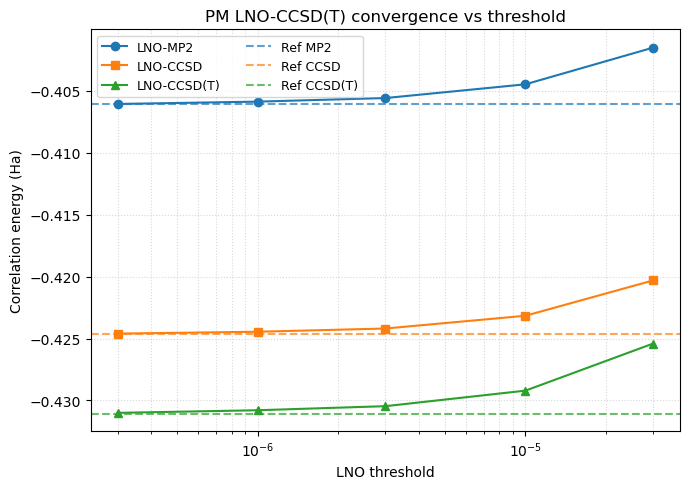

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Computed LNO values vs threshold
ax.plot(threshs, emp2_pm,    'o-', color='tab:blue',   label='LNO-MP2')
ax.plot(threshs, eccsd_pm,   's-', color='tab:orange', label='LNO-CCSD')
ax.plot(threshs, eccsd_t_pm, '^-', color='tab:green',  label='LNO-CCSD(T)')

# Reference (full) values as horizontal dashed lines, color-matched
ax.axhline(efull_mp2,    ls='--', color='tab:blue',   alpha=0.7, label='Ref MP2')
ax.axhline(efull_ccsd,   ls='--', color='tab:orange', alpha=0.7, label='Ref CCSD')
ax.axhline(efull_ccsd_t, ls='--', color='tab:green',  alpha=0.7, label='Ref CCSD(T)')

ax.set_xscale('log')
# ax.invert_xaxis()  # smaller threshold (tighter) on the right -> easier to read convergence
ax.set_xlabel('LNO threshold')
ax.set_ylabel('Correlation energy (Ha)')
ax.set_title('PM LNO-CCSD(T) convergence vs threshold')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()
# ax.invert_xaxis()  # smaller threshold (tighter) on the right ->

In [3]:
# def test_lno_iao_by_thresh(self):
mol = mycc.mol
mf = mycc._scf
frozen = mycc.frozen

# IAO localization
orbocc = mf.mo_coeff[:,frozen:np.count_nonzero(mf.mo_occ)]
lo_coeff_iao = lo.iao.iao(mol, orbocc)
lo_coeff_iao = lo.orth.vec_lowdin(lo_coeff_iao, mf.get_ovlp())
moliao = lo.iao.reference_mol(mol)

# frag_lolist = autofrag_iao(moliao)

# gamma = 10
# threshs = [3e-5,1e-5,3e-6,1e-6,3e-7]
# # refs = [
# #     [-0.4054784012,-0.4240686326,-0.4303996712],
# #     [-0.4060479828,-0.4245745223,-0.4309965749],
# # ]

# emp2_iao = np.zeros(len(threshs))
# eccsd_iao = np.zeros(len(threshs))
# eccsd_t_iao = np.zeros(len(threshs))

# for i, thresh in enumerate(threshs):
#     mcc = LNOCCSD_T(mf, lo_coeff, frag_lolist, frozen=frozen).set(verbose=5)
#     mcc.lno_thresh = [thresh*gamma,thresh]
#     mcc.kernel()
#     emp2_iao[i] = mcc.e_corr_pt2
#     eccsd_iao[i] = mcc.e_corr_ccsd
#     eccsd_t_iao[i] = mcc.e_corr_ccsd_t

In [23]:
def olp(lo_coeff, mo_coeff, s1e):
    o = lo_coeff.T @ s1e @ mo_coeff
    return o

In [16]:
import numpy as np

def lo_in_mo_span(lo_coeff, mo_coeff, s1e, tol=1e-10):
    """
    Test whether span({|lo_i>}) is contained in span({|mo_j>}).
    Returns (contained: bool, diagnostics: dict).
    """
    L, M, S = lo_coeff, mo_coeff, s1e
    S_lo = L.conj().T @ S @ L
    S_mo = M.conj().T @ S @ M
    O    = L.conj().T @ S @ M           # same as olp(L, M, S)

    # Residual:  R = S_lo - O S_mo^{-1} O^†   (no explicit inverse)
    X = np.linalg.solve(S_mo, O.conj().T)
    R = S_lo - O @ X
    res_norm = np.linalg.norm(R)
    per_lo   = np.diag(R).real          # leakage of each individual LO

    # Principal angles: singular values of S_lo^{-1/2} O S_mo^{-1/2}
    def inv_sqrt(A):
        e, U = np.linalg.eigh(A)
        e = np.maximum(e, 1e-14)        # guard against tiny eigenvalues
        return (U * (1.0 / np.sqrt(e))) @ U.conj().T

    sigma = np.linalg.svd(inv_sqrt(S_lo) @ O @ inv_sqrt(S_mo),
                          compute_uv=False)

    n_lo, n_mo = L.shape[1], M.shape[1]
    contained = (n_lo <= n_mo) and np.all(np.abs(sigma - 1.0) < tol)

    return contained, {
        "residual_norm":     res_norm,     # 0 ⇔ inclusion
        "per_lo_residual":   per_lo,       # which LO leaks
        "singular_values":   sigma,        # cos(principal angles)
        "min_cos":           sigma.min() if sigma.size else None,
    }

In [ ]:
s1e = mf.get_ovlp()
# print(s1e)
# orbocc.T @ s1e @ orbocc
o = olp(orbocc,orbocc,s1e)
print(o)

[[ 1.00000000e+00  4.61436445e-16 -5.55111512e-17 -6.59194921e-17
  -9.71445147e-17  1.45716772e-16 -1.14491749e-16 -2.77555756e-17]
 [ 4.67128506e-16  1.00000000e+00 -1.73472348e-18 -8.32667268e-17
   3.88578059e-16  8.04911693e-16  1.80411242e-16 -1.40946282e-17]
 [ 1.38777878e-17  0.00000000e+00  1.00000000e+00  1.04083409e-17
   1.38777878e-17  0.00000000e+00 -4.11996826e-18 -2.73218947e-17]
 [-4.16333634e-17 -5.55111512e-17  6.93889390e-18  1.00000000e+00
   2.08166817e-16  2.22044605e-16  5.55111512e-17  5.69206141e-17]
 [-5.55111512e-17  3.26128013e-16  2.77555756e-17  1.59594560e-16
   1.00000000e+00  2.96637714e-16  3.95516953e-16 -4.07660017e-17]
 [ 1.04083409e-16  6.38378239e-16  1.04083409e-17  8.32667268e-17
   2.87530416e-16  1.00000000e+00  6.41847686e-17  4.16333634e-17]
 [-1.45716772e-16  1.39645240e-16 -8.67361738e-19 -2.77555756e-17
   4.85722573e-16  1.14491749e-16  1.00000000e+00  5.75711354e-17]
 [-3.27429056e-17 -1.38777878e-17 -2.68882139e-17  5.69206141e-17
  -

In [32]:
lo_in_mo_span(lo_coeff_pm, orbocc, s1e, tol=1e-10)

(np.True_,
 {'residual_norm': np.float64(6.864065387674695e-16),
  'per_lo_residual': array([ 0.00000000e+00, -2.22044605e-16,  0.00000000e+00, -1.11022302e-16,
          0.00000000e+00,  0.00000000e+00,  2.22044605e-16,  0.00000000e+00]),
  'singular_values': array([1., 1., 1., 1., 1., 1., 1., 1.]),
  'min_cos': np.float64(0.9999999999999996)})

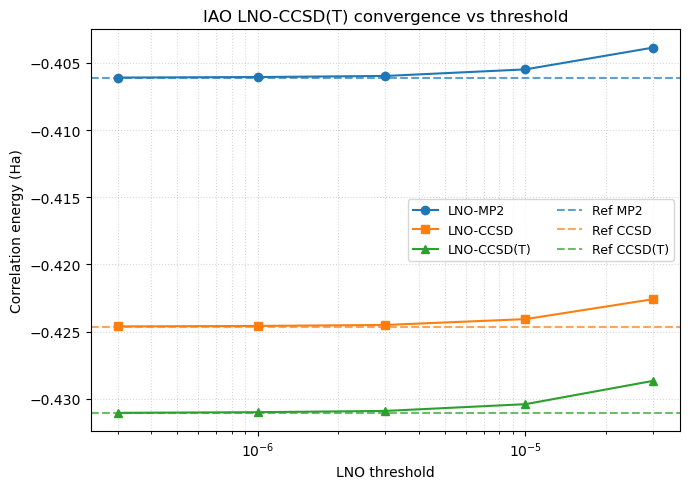

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Computed LNO values vs threshold
ax.plot(threshs, emp2_iao,    'o-', color='tab:blue',   label='LNO-MP2')
ax.plot(threshs, eccsd_iao,   's-', color='tab:orange', label='LNO-CCSD')
ax.plot(threshs, eccsd_t_iao, '^-', color='tab:green',  label='LNO-CCSD(T)')

# Reference (full) values as horizontal dashed lines, color-matched
ax.axhline(efull_mp2,    ls='--', color='tab:blue',   alpha=0.7, label='Ref MP2')
ax.axhline(efull_ccsd,   ls='--', color='tab:orange', alpha=0.7, label='Ref CCSD')
ax.axhline(efull_ccsd_t, ls='--', color='tab:green',  alpha=0.7, label='Ref CCSD(T)')

ax.set_xscale('log')
# ax.invert_xaxis()  # smaller threshold (tighter) on the right -> easier to read convergence
ax.set_xlabel('LNO threshold')
ax.set_ylabel('Correlation energy (Ha)')
ax.set_title('IAO LNO-CCSD(T) convergence vs threshold')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
print(lo_coeff_pm.shape)
print(lo_coeff_iao.shape)

(48, 8)
(48, 14)


In [27]:
# identify the center LO's AO component
# print(f'Locating local orbital {loidx[spin_idx]}')
# print(orbloc[0].shape, orbloc[1].shape)
def ao_proj(mol, lo_coeff):
    S = mol.intor('int1e_ovlp')
    proj = (S @ lo_coeff)**2
    # print(len(proj.shape))
    proj = proj / np.sum(proj, axis=0)
    if len(proj.shape) == 2:
        proj = np.sum(proj, axis=1)
    # print(proj.shape)
    ao_labels = mol.ao_labels()
    ao_threshold = 1e-3
    above = np.where(proj > ao_threshold)[0]
    # sort them by contribution descending
    above = above[np.argsort(proj[above])[::-1]]
    ao_lines = []
    print(f"AOs with contribution > {ao_threshold}")
    ao_lines.append(f"AOs with contribution > {ao_threshold}")
    print(f"{'AO Label':>16s}  {'Amp':>6s}")
    ao_lines.append(f"{'AO Label':>16s}  {'Amp':>6s}")
    for idx in above:
        print(f"{ao_labels[idx]:>16s}  {proj[idx]:6.4f}")
        ao_lines.append(f"{ao_labels[idx]:>16s}  {proj[idx]:6.4f}") 
    ao_message = "\n".join(ao_lines)
    return ao_message

In [23]:
from pyscf.lno.tools import autofrag_iao
orbocc = mf.mo_coeff[:,frozen:np.count_nonzero(mf.mo_occ)]
lo_coeff_iao = lo.iao.iao(mol, orbocc)
lo_coeff_iao = lo.orth.vec_lowdin(lo_coeff_iao, mf.get_ovlp())
moliao = lo.iao.reference_mol(mol)
frag_lolist = autofrag_iao(moliao)

print(frag_lolist)

[[0, 1, 2, 3, 4], [5], [6], [7, 8, 9, 10, 11], [12], [13]]


In [40]:
ao_proj(mol,lo_coeff_iao[:,7:12])

AOs with contribution > 0.001
        AO Label     Amp
      3 O 1s      0.9015
      3 O 2pz     0.5215
      3 O 2py     0.4675
      3 O 2px     0.4671
      3 O 2s      0.4192
      3 O 3py     0.3580
      3 O 3px     0.3555
      3 O 3s      0.3027
      3 O 3pz     0.2283
      5 H 2pz     0.1641
      4 H 2pz     0.1641
      5 H 2py     0.1096
      4 H 2py     0.1096
      5 H 2px     0.0880
      4 H 2px     0.0880
      4 H 1s      0.0799
      5 H 1s      0.0799
      5 H 2s      0.0323
      4 H 2s      0.0323
      2 H 2s      0.0214
      2 H 2px     0.0066


'AOs with contribution > 0.001\n        AO Label     Amp\n      3 O 1s      0.9015\n      3 O 2pz     0.5215\n      3 O 2py     0.4675\n      3 O 2px     0.4671\n      3 O 2s      0.4192\n      3 O 3py     0.3580\n      3 O 3px     0.3555\n      3 O 3s      0.3027\n      3 O 3pz     0.2283\n      5 H 2pz     0.1641\n      4 H 2pz     0.1641\n      5 H 2py     0.1096\n      4 H 2py     0.1096\n      5 H 2px     0.0880\n      4 H 2px     0.0880\n      4 H 1s      0.0799\n      5 H 1s      0.0799\n      5 H 2s      0.0323\n      4 H 2s      0.0323\n      2 H 2s      0.0214\n      2 H 2px     0.0066'

In [36]:
moliao.aoslice_by_atom()

array([[ 0,  2,  0,  5],
       [ 2,  3,  5,  6],
       [ 3,  4,  6,  7],
       [ 4,  6,  7, 12],
       [ 6,  7, 12, 13],
       [ 7,  8, 13, 14]])

In [21]:
cs = mol.atom_charges()
rs = mol.atom_coords()
print(cs)
print(rs)

[8 1 1 8 1 1]
[[-2.80655197 -0.21679801  0.        ]
 [-3.53079329  1.44053527  0.        ]
 [-1.00879882  0.07654796  0.        ]
 [ 2.67673782  0.21025931  0.        ]
 [ 3.29991847 -0.7066547  -1.43347254]
 [ 3.29991847 -0.7066547   1.43347254]]


In [ ]:
def autofrag_atom(mol, H2heavy=False):
    ''' Group non-ghost atoms into fragments. Return fragment definitions by
        atom indices

    Args:
        mol (gto.Mole or pbc.gto.Cell):
            PySCF Mole object.
        H2heavy (bool):
            Wether to include H atoms into the fragment of the nearest heavy
            atom (e.g., a CH3 group). Default is False, which means every atom
            defines an individual fragment.
            In case of no heavy atoms (e.g., a H chain), this variable is ignored
            and every H atom defines a fragment.

    Return:
        frag_atmlist (nested list):
            Fragment definition by atom indices. E.g., [[0],[1,5],[2,3,4],...] means
                fragment 1 consists of atom 0
                fragment 2 consists of atom 1 and 5
                fragment 3 consists of atom 2, 3, and 4
                ...
    '''
    if H2heavy:
        get_dist = lambda x,y: ((x[:,None,:]-y)**2.).sum(axis=-1)

        if hasattr(mol, 'lattice_vectors'):  # mol is actually a Cell object
            alat = mol.lattice_vectors()
        else:
            alat = None
        cs = mol.atom_charges()
        rs = mol.atom_coords()
        idx_H = np.where(cs == 1)[0]
        idx_X = np.where(cs > 1)[0]
        if idx_X.size > 0:
            if alat is None:
                d2 = get_dist(rs[idx_H], rs[idx_X])
                H2Xmap = np.argmin(d2, axis=1)
            else:
                d2 = []
                for jx in [-1,0,1]:
                    for jy in [-1,0,1]:
                        for jz in [-1,0,1]:
                            a = np.dot(np.array([jx,jy,jz]), alat)
                            d2.append( get_dist(rs[idx_H], rs[idx_X]+a) )
                d2 = np.hstack(d2)
                H2Xmap = np.argmin(d2, axis=1) % len(idx_X)
            frag_atmlist = [None] * len(idx_X)
            for i,iX in enumerate(idx_X):
                iHs = np.where(H2Xmap==i)[0]
                l = np.asarray(np.concatenate([[iX], idx_H[iHs]]),
                               dtype=int).tolist()
                frag_atmlist[i] = l
        else:   # all-H system
            print('warning: no heavy atom detected in the system; every '
                  'hydrogen atom is treated as a single fragment.')
            frag_atmlist = [[i] for i in idx_H]
    else:
        frag_atmlist = [[i] for i in np.where(mol.atom_charges() > 0)[0]]

    return frag_atmlist

def autofrag_iao(moliao, frag_type='atom', frag_atmlist=None):
    ''' Group IAOs into fragments. Return fragment definitions by IAO indices.

    Args:
        moliao (gto.Mole or pbc.gto.Cell):
            Mole/Cell object generated by `lo.iao.reference_mol`.
        frag_atmlist (nested list):
            Fragment definitions by atom indices. If not provided, `autofrag_atom`
            will be called to generate a `frag_atmlist` using `moliao` with
            `H2heavy` set to False.
        frag_type (str, case insensitive):
            How IAOs are grouped into fragments:
                'atom' (default):
                    All IAOs on an atom define a fragment.
                'shell':
                    Each shell of IAOs on an atom define a fragment.
                    E.g., 3 fragments per carbon atom, 1s, 2s and 2p.
                'shell deep':
                    Shells of IAOs sharing same angular momentum on an atom define
                    a fragment. E.g., 2 fragments per carbon atom, 1s+2s and 2p.
                '1o' or 'orbital':
                    Each IAO defines a fragment. Note that this choice leads
                    to energy not invariant to rotations of a molecule.

    Returns:
        frag_lolist (nested list):
            Fragment definition by IAO indices. E.g., [[0],[1,5],[2,3,4],...] means
                fragment 1 consists of IAO 0
                fragment 2 consists of IAO 1 and 5
                fragment 3 consists of IAO 2, 3, and 4
                ...
    '''
    frag_type = frag_type.lower()
    if frag_type == '1o' or frag_type.startswith('orb'):
        frag_lolist = [[i] for i in range(moliao.nao_nr())]
    elif frag_type.startswith('at'):
        if frag_atmlist is None: frag_atmlist = autofrag_atom(moliao)
        frag_lolist = [np.hstack([range(p0,p1) for (b0,b1,p0,p1) in
                                  moliao.aoslice_by_atom()[atom_ids]]).tolist()
                       for atom_ids in frag_atmlist]
    elif frag_type == 'shell':
        nbas = moliao.nbas
        ao_loc = moliao.ao_loc_nr()
        frag_lolist = [list(range(*ao_loc[i:i+2])) for i in range(nbas)]
    elif frag_type == 'shell deep':
        from pyscf import lib
        nbas = moliao.nbas
        ao_loc = moliao.ao_loc_nr()
        bas_nao = ao_loc[1:] - ao_loc[:-1]
        bas_ls = np.asarray([moliao.bas_angular(i) for i in range(nbas)])
        bas_nao0_sph = 2*bas_ls+1
        bas_nao0_cart = (bas_ls+1)*(bas_ls+2)//2
        if np.all(bas_nao%bas_nao0_sph == 0):
            bas_nao0 = bas_nao0_sph
        elif np.all(bas_nao%bas_nao0_cart == 0):
            bas_nao0 = bas_nao0_cart
        else:
            raise RuntimeError
        frag_lolist = [list(range(p0,p1)) for i in range(nbas) for p0,p1 in
                       lib.prange(*ao_loc[i:i+2],bas_nao0[i])]
    else:
        raise ValueError('Unknown frag_type %s' % (str(frag_type)))
    return frag_lolist